<center><u><H1>Random Forest</H1></u></center>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
%matplotlib inline

In [2]:
iris = load_iris()

## Preprocessing:

In [3]:
X = iris.data
y = iris.target

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=2018)

## Creating a model

In [5]:
rf = RandomForestClassifier(n_estimators=100)

In [6]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Making Predictions:

In [7]:
rf.predict(iris.data[:1, :])

array([0])

In [8]:
rf.predict_proba(iris.data[:1, :])

array([[1., 0., 0.]])

## Metrics:

In [9]:
rf_pred = rf.predict(X_test)

In [10]:
print(accuracy_score(y_test,rf_pred))

0.9555555555555556


In [11]:
print(confusion_matrix(y_test,rf_pred))

[[18  0  0]
 [ 0 11  0]
 [ 0  2 14]]


In [13]:
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.85      1.00      0.92        11
           2       1.00      0.88      0.93        16

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.95        45
weighted avg       0.96      0.96      0.96        45



## Cross Validation:

In [14]:
cross_val_score(rf, X, y, cv=10).mean()

np.float64(0.96)

## Feature Importance:

In [15]:
features = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']

In [16]:
list(zip(features, rf.feature_importances_))

[('sepal length (cm)', np.float64(0.11110833854977133)),
 ('sepal width (cm)', np.float64(0.021367097037728693)),
 ('petal length (cm)', np.float64(0.46222391323495804)),
 ('petal width (cm)', np.float64(0.40530065117754194))]

## Plotting Decision Boundaries:

In [17]:
def plot_regions(X, y, classifier):
    n_classes = len(np.unique(y))
    plot_colors = ["blue","orange","green"]
    res = 0.02

    for idx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
        
        X = iris.data[:, pair]
        # Train
        clf = classifier.fit(X, y)

        # Plot the decision boundary
        fig = plt.figure(1,figsize=(14, 10))
        plt.subplot(2, 3, idx + 1)

        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, res), np.arange(y_min, y_max, res))
        
        output = clf.predict(np.array([xx.ravel(), yy.ravel()]).T)
        output = output.reshape(xx.shape)
        plt.pcolormesh(xx,yy, output, cmap=plt.cm.gist_rainbow)
        
        plt.xlabel(iris.feature_names[pair[0]])
        plt.ylabel(iris.feature_names[pair[1]])
        
        # Plot the training points
        for nc, color in zip(range(n_classes), plot_colors):
            plt.scatter(X[y==nc, 0], X[y==nc, 1], c=color, label=iris.target_names[nc])
          
    plt.suptitle("Random Forest")
    plt.legend(loc='best')
    plt.show()

C:\Users\nvpra\AppData\Local\Temp\ipykernel_31924\2800527035.py:14: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1,figsize=(14, 10))
C:\Users\nvpra\AppData\Local\Temp\ipykernel_31924\2800527035.py:14: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1,figsize=(14, 10))
C:\Users\nvpra\AppData\Local\Temp\ipykernel_31924\2800527035.py:14: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1,figsize=(14, 10))
C:\Users\nvpra\AppData\Local\Temp\ipykernel_31924\2800527035.py:14: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(1,figsize=(14, 10))
C:\Users\nvpra\AppData\Local\Temp\ipykernel_31924\2800527035.py:14: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  fig = plt.figure(

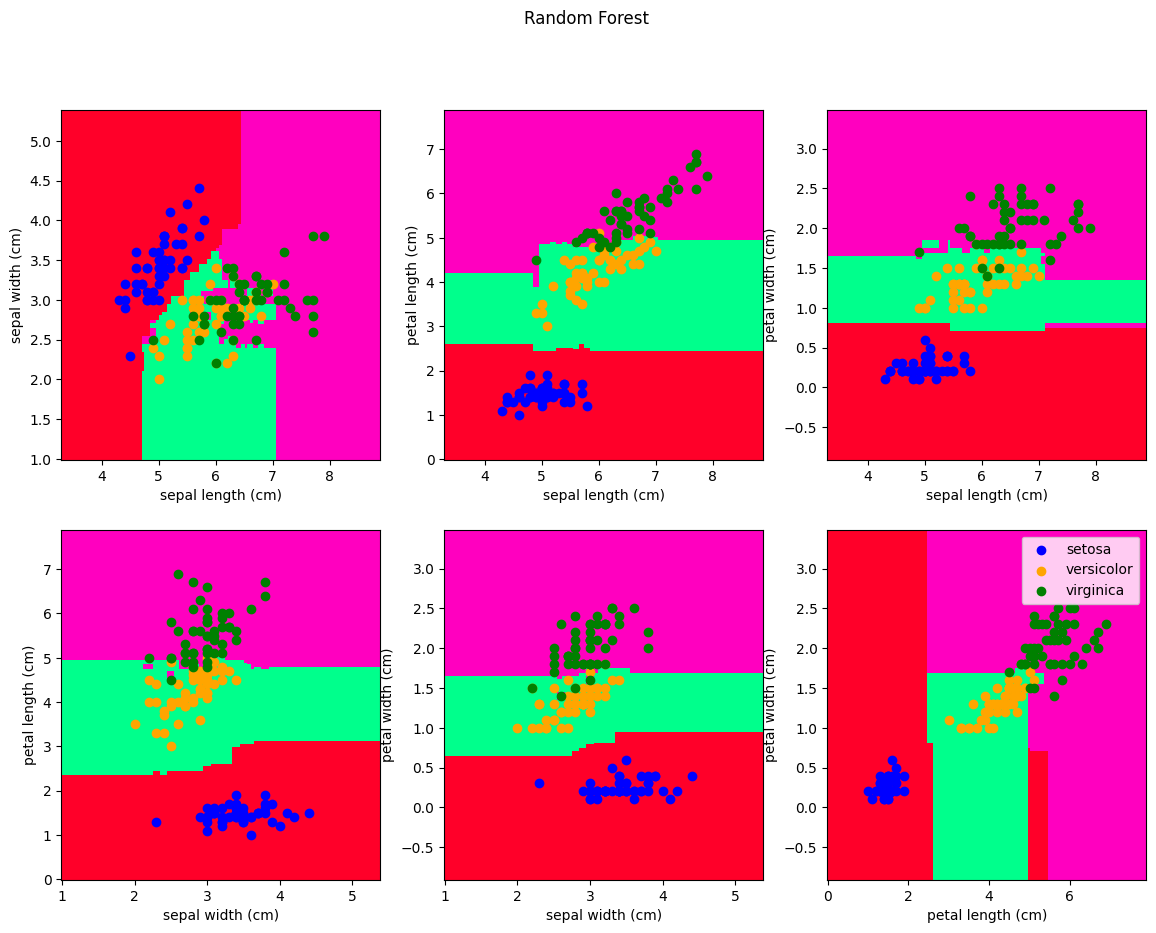

In [18]:
new_rf = RandomForestClassifier(n_estimators=100)
plot_regions(X=iris.data,y=iris.target,classifier=new_rf)

## Reference: 

http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html